# FedProx for Non-IID Federated Learning

## Objective

This notebook evaluates the FedProx algorithm under the same extreme Non-IID setting used in the previous experiment.

The objective is to determine whether FedProx can mitigate client drift and improve performance compared to FedAvg.


In [1]:
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset


## Environment Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


## Experimental Configuration

- Number of Clients: 5
- Communication Rounds: 5
- Local Epochs: 1
- Non-IID Distribution
- FedProx Coefficient (μ): configurable


In [3]:
NUM_CLIENTS = 5
ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
LR = 0.001

MU = 0.01


## Non-IID Dataset Construction

Client Distribution:

- Client 1 → Digits (0,1)
- Client 2 → Digits (2,3)
- Client 3 → Digits (4,5)
- Client 4 → Digits (6,7)
- Client 5 → Digits (8,9)


In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

targets = train_dataset.targets

client_digit_groups = [(0,1),(2,3),(4,5),(6,7),(8,9)]

client_datasets = []

for d1, d2 in client_digit_groups:

    indices = ((targets == d1) | (targets == d2)).nonzero(as_tuple=True)[0]

    client_datasets.append(
        Subset(train_dataset, indices)
    )


100%|██████████| 9.91M/9.91M [00:00<00:00, 136MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 30.6MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 113MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.87MB/s]


In [5]:
client_loaders = [
    DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    for ds in client_datasets
]

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [6]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,32,3)
        self.conv2 = nn.Conv2d(32,64,3)

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64*12*12,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))

        x = self.pool(x)

        x = x.view(x.size(0),-1)

        x = torch.relu(self.fc1(x))

        return self.fc2(x)


## FedProx Local Training

FedProx extends FedAvg by introducing a proximal term that penalizes excessive deviation from the global model.

Loss:

CrossEntropy + (μ/2) × Proximal Term


In [7]:
def train_local_model_fedprox(
    model,
    global_model,
    loader
):

    model.train()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR
    )

    criterion = nn.CrossEntropyLoss()

    for _ in range(LOCAL_EPOCHS):

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            ce_loss = criterion(
                outputs,
                labels
            )

            prox_term = 0.0

            for local_param, global_param in zip(
                model.parameters(),
                global_model.parameters()
            ):

                prox_term += (
                    torch.norm(
                        local_param - global_param,
                        p=2
                    ) ** 2
                )

            loss = ce_loss + (MU / 2) * prox_term

            loss.backward()

            optimizer.step()

    return model


In [8]:
def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


In [9]:
def federated_average(client_models):

    global_model = copy.deepcopy(client_models[0])

    state = global_model.state_dict()

    for key in state:

        state[key] = torch.stack(
            [m.state_dict()[key].float() for m in client_models],
            dim=0
        ).mean(dim=0)

    global_model.load_state_dict(state)

    return global_model


## Federated Training

In [10]:
global_model = CNN().to(device)

accuracy_history = []


In [11]:
for round_num in range(ROUNDS):

    print(f'Round {round_num+1}')

    client_models = []

    for loader in client_loaders:

        local_model = copy.deepcopy(global_model)

        local_model = train_local_model_fedprox(
            local_model,
            global_model,
            loader
        )

        client_models.append(local_model)

    global_model = federated_average(client_models)

    accuracy = evaluate(
        global_model,
        test_loader
    )

    accuracy_history.append(accuracy)

    print(f'Accuracy: {accuracy:.2f}%')


Round 1
Accuracy: 51.30%
Round 2
Accuracy: 64.11%
Round 3
Accuracy: 74.92%
Round 4
Accuracy: 83.95%
Round 5
Accuracy: 85.60%


## Convergence Analysis

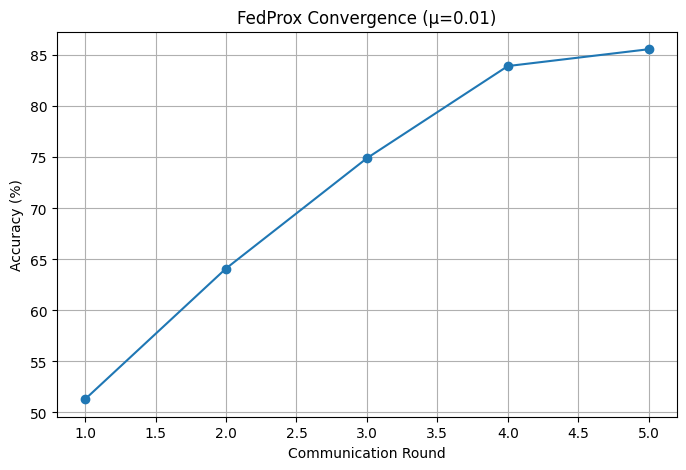

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,ROUNDS+1),
    accuracy_history,
    marker='o'
)

plt.xlabel('Communication Round')
plt.ylabel('Accuracy (%)')
plt.title(f'FedProx Convergence (μ={MU})')

plt.grid()

plt.savefig(
    'fedprox_non_iid_accuracy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## Results

In [14]:
print('Reference Results')
print('FedAvg Non-IID  : 71.50%')
print('FedProx μ=0.001 : 82.98%')
print('FedProx μ=0.01  : 85.60%')
print('FedProx μ=0.1   : 73.88%')


print()
print(f'Current Run     : {accuracy_history[-1]:.2f}%')


Reference Results
FedAvg Non-IID  : 71.50%
FedProx μ=0.001 : 82.98%
FedProx μ=0.01  : 85.60%
FedProx μ=0.1   : 73.88%

Current Run     : 85.60%


## Conclusion

FedProx significantly improves performance under extreme Non-IID conditions.

Observed results:

- FedAvg Non-IID: 71.5%
- FedProx (μ=0.001): 82.98%
- FedProx (μ=0.01): 85.6%
- FedProx (μ=0.1): 73.88%

The best performance was achieved with μ = 0.01, demonstrating that an appropriate proximal constraint can reduce client drift and improve federated optimization.
